In [1]:
import sys
import torch

sys.path.append('..')

from PySESM.models.SESM.SESM import SESM_Model
from PySESM.test_functions.MultivariateNormal import MultivariateNormal
from PySESM.base_functions.Function import GaussianFunctions

In [2]:
n_samples = 1000
n_features = 2
l_functions = 15

In [3]:
mu_1 = torch.tensor([1, 1])
mu_2 = torch.tensor([1, -1])
mu_3 = torch.tensor([-1, -1])

sigma_1 = 0.15 * torch.eye(n_features)
sigma_2 = 0.2 * torch.eye(n_features)
sigma_3 = 0.3 * torch.eye(n_features)

means = [mu_1, mu_2, mu_3]
covariances = [sigma_1, sigma_2, sigma_3]
scale_factors = torch.tensor([1.0, .5, 1.5])

In [4]:
mvn_1 = MultivariateNormal(n_features, means, covariances, scale_factors)

In [5]:
X, y = mvn_1.sample_n(n_samples)

print(X.shape)
print(y.shape)

torch.Size([1000, 2])
torch.Size([1000])


/home/rijegaro/.local/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
gaussian_function = GaussianFunctions(n_features=n_features, n_functions=l_functions)

In [7]:
model = SESM_Model(
    n_samples=n_samples,
    n_features=n_features,
    n_functions=l_functions,
    psi=gaussian_function.gaussian
)

In [8]:
model_epochs = 30
ista_epochs = 100   
dictionary_epochs = 60

ista_alpha = 0.02
ista_lambd = 0.001

dictionary_alpha = 0.02

model.fit(
    X=X,
    y=y,
    model_epochs=model_epochs,
    ista_epochs=ista_epochs,
    ista_alpha=ista_alpha,
    ista_lambd=ista_lambd,
    dictionary_epochs=dictionary_epochs,
    dictionary_alpha=dictionary_alpha
)

Epoch 1 Loss: 1.9600703716278076

Epoch 2 Loss: 0.39253371953964233

Epoch 3 Loss: 0.1369001418352127

Epoch 4 Loss: 0.06523622572422028

Epoch 5 Loss: 0.0400499626994133

Epoch 6 Loss: 0.029315229505300522

Epoch 7 Loss: 0.023725025355815887

Epoch 8 Loss: 0.020237233489751816

Epoch 9 Loss: 0.017735688015818596

Epoch 10 Loss: 0.015769435092806816

Epoch 11 Loss: 0.014145845547318459

Epoch 12 Loss: 0.012772445566952229

Epoch 13 Loss: 0.011593489907681942

Epoch 14 Loss: 0.010571523569524288

Epoch 15 Loss: 0.00967943761497736

Epoch 16 Loss: 0.008896472863852978

Epoch 17 Loss: 0.008206169120967388

Epoch 18 Loss: 0.007595139089971781

Epoch 19 Loss: 0.007056184578686953

Epoch 20 Loss: 0.006578080356121063

Epoch 21 Loss: 0.00615077605471015

Epoch 22 Loss: 0.005767445545643568

Epoch 23 Loss: 0.005422407295554876

Epoch 24 Loss: 0.005110852420330048

Epoch 25 Loss: 0.0048286751843988895

Epoch 26 Loss: 0.004572352394461632

Epoch 27 Loss: 0.00433884235098958

Epoch 28 Loss: 0.004

In [12]:
plot_n_samples = 50

samples = []

for n in range(n_features):
    feature = torch.linspace(-2, 2, plot_n_samples)
    samples.append(feature)

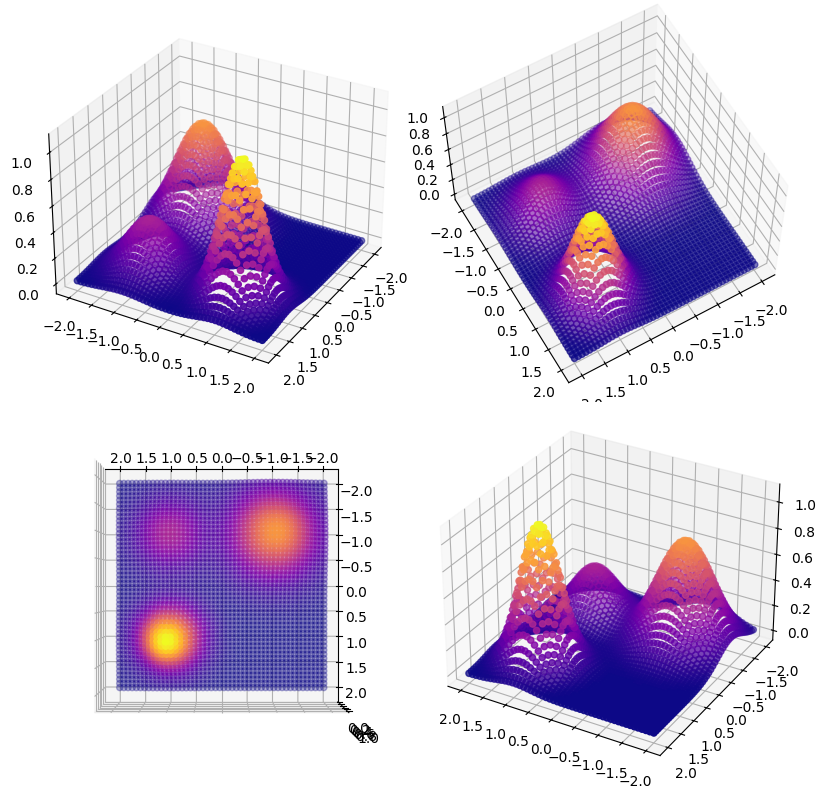

In [15]:
mvn_1.plot(plot_n_samples, samples)

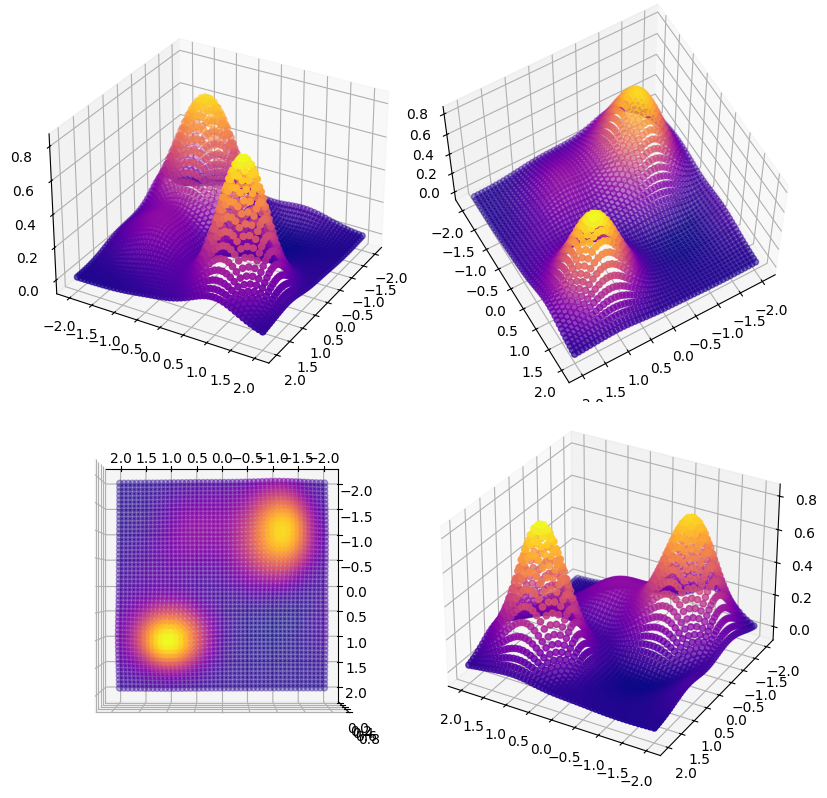

In [22]:
model.plot(plot_n_samples, samples)

In [ ]:
print(f'Duración del modelo: {model.time / 60:.2f} minutos')

In [ ]:
model.plot_loss()